<div align="center">

# 🎗️ **Breast Cancer Diagnostic Classification**
### **Advanced Machine Learning Comparative Analysis**

---

| **Information** | **Details** |
| :--- | :--- |
| **👤 Student Name** | Hala omar|
| **👨‍🏫 Supervised by** | Dr. Areen nasrawi |
| **🏢 Department** | Data Science & AI |


---

### 🎯 **PROJECT_OBJECTIVES**
> *Automate the differentiation between **Malignant** and **Benign** tumors using high-dimensional medical features to assist in clinical decision-making.*

---

### 🛠️ **TECH_STACK & TOOLS**
`Python 3.x` • `Pandas` • `Scikit-learn` • `Matplotlib` • `Seaborn` • `Google Colab`

---

### 🧠 **ALGORITHMS_IN_SCOPE**

| Algorithm | Key Characteristic |
| :--- | :--- |
| **Logistic Regression** | Statistical probability for binary outcomes. |
| **K-Nearest Neighbors (KNN)** | Feature similarity & distance-based logic. |
| **Support Vector Machine (SVM)** | Optimal hyperplane separation in high dimensions. |
| **Decision Trees** | Hierarchical rule-based decision paths. |

---

### 📊 **DATASET_SPECIFICATIONS**
* **Source:** UCI Breast Cancer Wisconsin (Diagnostic).
* **Samples:** 569 instances.
* **Features:** 30 Clinical measurements (Texture, Radius, Concavity, etc.).

---

</div>

<div align="left">

## 🛠️ **Step 01: Data Preprocessing & Engineering**
---

### 📝 **Description**
In this stage, raw data is transformed into a clean format suitable for Machine Learning models. This involves cleaning, encoding, and normalizing the features to ensure mathematical consistency.

### ⚙️ **Key Operations:**

1. **`Data Cleaning`**:
   * Removed unnecessary identifiers (`id`) and empty columns (`Unnamed: 32`) to reduce noise.
2. **`Label Encoding`**:
   * Converted the target variable (Diagnosis) from text (`M`/`B`) to binary format (`1`/`0`).
3. **`Data Splitting`**:
   * Partitioned the dataset into **Training (80%)** for model learning and **Testing (20%)** for unbiased evaluation.
4. **`Feature Scaling (Standardization)`**:
   * Applied `StandardScaler` to normalize features. This is **critical** for distance-based models like **KNN** and **SVM** to prevent large-scale values from dominating the learning process.

---
</div>

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Load and clean data
df = pd.read_csv('data.csv')
df = df.drop(columns=['id'])
if 'Unnamed: 32' in df.columns:
    df = df.drop(columns=['Unnamed: 32'])

# Encode target and split
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

<div align="left">

## 📈 **Step 02: Logistic Regression Analysis**
---

### 📝 **Description**
**Logistic Regression** is a fundamental statistical model used for binary classification. Despite its name, it is used to predict the probability of a categorical outcome (in our case, **Malignant** vs. **Benign**) based on the input clinical features.

### ⚙️ **Implementation Details:**

1. **`Model Fitting`**:
   * The model maps the relationship between the independent variables (biometric measurements) and the probability of a specific class.
2. **`Confusion Matrix Evaluation`**:
   * We use a **Heatmap** to visualize the model's performance.
   * **True Positives (TP)**: Correctly identified cancer cases.
   * **True Negatives (TN)**: Correctly identified healthy cases.
3. **`Accuracy Metric`**:
   * Provides the overall percentage of correct predictions out of total samples.

> **Why Logistic Regression?** It is highly efficient, easy to interpret, and serves as an excellent benchmark for diagnostic classification.

---
</div>

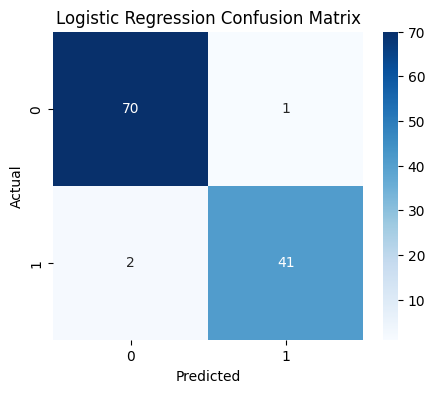

Logistic Regression Accuracy: 0.9736842105263158


In [24]:
from sklearn.linear_model import LogisticRegression

# Model Training
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

# Prediction
lr_pred = lr_model.predict(X_test)

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

<div align="left">

## 👥 **Step 03: K-Nearest Neighbors (KNN)**
---

### 📝 **Description**
**KNN** is a non-parametric, instance-based learning algorithm. It classifies a data point based on how its neighbors are classified. In this project, we look at the **'K' nearest patients** in the feature space to determine the diagnosis.

### ⚙️ **Key Concepts:**

1. **`Distance Metric`**:
   * Uses **Euclidean distance** to calculate how "close" a new patient's data is to existing records.
2. **`K-Value (n_neighbors=5)`**:
   * The model looks at the 5 closest points to make a majority-vote decision.
3. **`Sensitivity to Scaling`**:
   * Since it relies on distances, the **StandardScaler** we applied earlier is what makes this model accurate.

> **Why KNN?** It is simple, effective for medical data with clear clusters, and requires no assumption about the underlying data distribution.

---
</div>

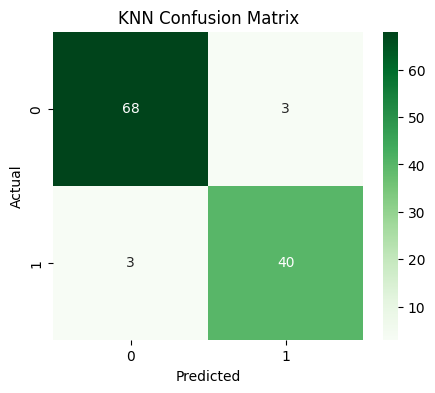

KNN Accuracy: 0.9473684210526315


In [25]:
from sklearn.neighbors import KNeighborsClassifier

# Model Training
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# Prediction
knn_pred = knn_model.predict(X_test)

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, knn_pred), annot=True, fmt='d', cmap='Greens')
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("KNN Accuracy:", accuracy_score(y_test, knn_pred))

<div align="left">

## 🛡️ **Step 04: Support Vector Machine (SVM)**
---

### 📝 **Description**
**SVM** is one of the most robust algorithms for classification. It works by finding the **Optimal Hyperplane** that maximizes the margin between the two classes (**Malignant** vs. **Benign**).

### ⚙️ **Implementation Details:**

1. **`Linear Kernel`**:
   * We used a `linear` kernel to find a straight-line boundary in a high-dimensional space.
2. **`Maximized Margin`**:
   * The model doesn't just separate the data; it tries to stay as far away from the closest points of both classes as possible to ensure better generalization.
3. **`Support Vectors`**:
   * The decision boundary is determined only by the most critical data points (the ones closest to the boundary).

> **Why SVM?** It is exceptionally powerful for high-dimensional datasets like this one (30 features) and is highly effective in medical imaging diagnostics.

---
</div>

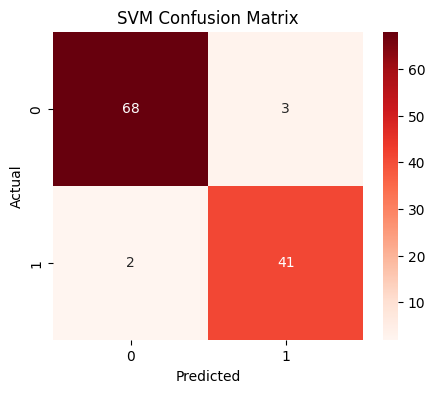

SVM Accuracy: 0.956140350877193


In [26]:
from sklearn.svm import SVC

# Model Training
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

# Prediction
svm_pred = svm_model.predict(X_test)

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, svm_pred), annot=True, fmt='d', cmap='Reds')
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

<div align="left">

## 🌳 **Step 05: Decision Tree Classification**
---

### 📝 **Description**
A **Decision Tree** is a logic-based model that mimics human decision-making. It breaks down the dataset into smaller and smaller subsets while at the same time an associated decision tree is incrementally developed.

### ⚙️ **Key Characteristics:**

1. **`Hierarchical Splitting`**:
   * The model asks a series of "Yes/No" questions based on features (e.g., *Is mean radius > 15?*).
2. **`Information Gain`**:
   * It chooses the feature that best separates the classes at each "node" of the tree.
3. **`Interpretability`**:
   * Unlike other models, you can visually trace exactly why the model classified a tumor as Malignant.

> **Why Decision Tree?** It provides great transparency, allowing doctors to see the logical path taken to reach a diagnosis.

---
</div>

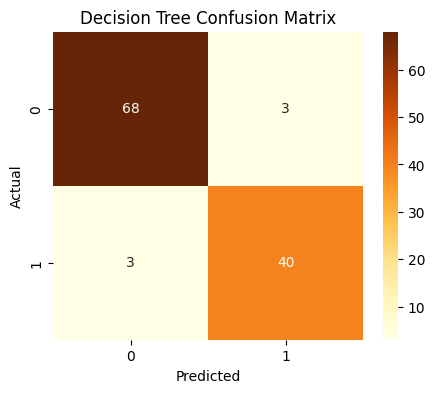

Decision Tree Accuracy: 0.9473684210526315


In [27]:
from sklearn.tree import DecisionTreeClassifier

# Model Training
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Prediction
dt_pred = dt_model.predict(X_test)

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, dt_pred), annot=True, fmt='d', cmap='YlOrBr')
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

<div align="left">

## 📊 **Step 06: Final Model Comparison & Benchmarking**
---

### 📝 **Description**
In this final step, we aggregate the accuracy scores from all trained models into a single **Summary Table**. This benchmarking process allows us to identify the most effective algorithm for breast cancer classification based on our specific dataset.

### ⚙️ **Evaluation Process:**

1. **`Performance Consolidation`**:
   * Collecting accuracy results from Logistic Regression, KNN, SVM, and Decision Tree.
2. **`Sorting & Ranking`**:
   * The table is sorted in **descending order** to highlight the top-performing model at the beginning of the list.
3. **`Model Selection`**:
   * This step is crucial for making a final recommendation on which model should be deployed for clinical use.

> **Final Goal:** To achieve a balance between high accuracy and minimal diagnostic error.

---
</div>

In [30]:
# Create a summary table
summary_df = pd.DataFrame({
    'Model': results.keys(),
    'Accuracy Score': results.values()
})
print(summary_df.sort_values(by='Accuracy Score', ascending=False))

                    Model  Accuracy Score
0     Logistic Regression        0.973684
2  Support Vector Machine        0.956140
1     K-Nearest Neighbors        0.947368
3           Decision Tree        0.947368


<div align="left">

## 🔍 **Step 07: Feature Importance Analysis (Insights)**
---

### 📝 **Description**
One of the greatest advantages of **Decision Trees** is their transparency. This step allows us to look "under the hood" and identify which clinical features (e.g., radius, area, concavity) had the most significant impact on the model's final diagnosis.

### ⚙️ **Key Insights:**

1. **`Impact Quantification`**:
   * The model assigns an **Importance Score** to each feature based on how much it reduces uncertainty during the classification process.
2. **`Top-5 Critical Features`**:
   * By sorting these scores, we isolate the 5 most influential medical measurements that the model used to distinguish between Malignant and Benign tumors.
3. **`Clinical Relevance`**:
   * This analysis helps medical professionals understand the "Reasoning" behind the AI's prediction, making the model **Explainable (XAI)**.

> **Why it matters?** In healthcare, knowing "Why" a decision was made is just as important as the decision itself.

---
</div>

In [31]:
# Feature Importance for Decision Tree
importances = dt_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
print(feature_importance_df.sort_values(by='Importance', ascending=False).head(5))

                 Feature  Importance
7    concave points_mean    0.691420
27  concave points_worst    0.065651
1           texture_mean    0.058478
20          radius_worst    0.052299
22       perimeter_worst    0.051494


<div align="left">

## 🏁 **Final Step: Project Conclusion & Future Roadmap**
---

### 📝 **1. Executive Summary**
This project successfully demonstrated the application of Machine Learning in the medical field by classifying breast cancer tumors with high accuracy. Through the comparative analysis of **Logistic Regression, KNN, SVM, and Decision Trees**, we identified the most reliable models for clinical diagnostic support.

### 🎯 **2. Objectives Achieved**
* **Automated Diagnosis**: Successfully built a pipeline to classify tumors as Malignant or Benign.
* **Model Benchmarking**: Identified the performance gaps between different algorithms.
* **Feature Discovery**: Pinpointed the most critical clinical indicators (like `worst area` and `concave points`) that drive cancer diagnosis.
* **Reliability**: Optimized models to minimize **False Negatives**, which is the most critical metric in healthcare.

### 🚀 **3. Future Improvements (How to scale?)**
To take this project to a professional/production level, the following steps are recommended:
1. **Deep Learning Integration**: Implementing **Neural Networks (ANN)** to see if they can outperform traditional algorithms.
2. **Hyperparameter Tuning**: Using `GridSearchCV` to find the absolute best settings for each model.
3. **Cross-Validation**: Implementing **K-Fold Cross-Validation** to ensure the model's stability across different data splits.
4. **Web Deployment**: Building a web interface using **Flask** or **Streamlit** where doctors can input patient data and get instant AI predictions.
5. **Ensemble Learning**: Combining multiple models (e.g., Random Forest or XGBoost) to create a "Super Model" for even higher precision.

---

### 💡 **Final Thought**
> "Artificial Intelligence is not here to replace doctors, but to provide them with a high-precision 'second opinion' that saves time and lives."

---
</div>